# T71 — K-Pg marine genus extinction selectivity: model vs. the fossil record

**Cluster J: Paleoclimate.**  *Datasets:* live [Paleobiology Database](https://paleobiodb.org) (PBDB) marine occurrences across the Maastrichtian-Danian boundary; cGENIE K-Pg biogeochemistry snapshots (Ying et al. 2026, CC BY 4.0, same bundle as T69/T70).

T69 showed the K-Pg impact winter as a global biogeochemical shock; T70 showed that, *within* the model's plankton community, body size and trophic strategy predict who collapsed. This notebook asks a harder, falsifiable question of the **real fossil record**: does the *local severity* of the modelled environmental shock at a fossil locality predict whether the genera found there went extinct? Or does extinction instead track something else — taxonomic identity, physiology, ecology — largely independent of local geography? Both are real, testable hypotheses, and (as in real research) the answer isn't guaranteed to be the more dramatic one.

## What this notebook produces

1. **§2 — Fetch PBDB marine occurrences live** across the Maastrichtian (pre-boundary) and Danian (post-boundary) stages, for six well-preserved marine groups.
2. **§3 — Genus-level survivorship.** A genus counts as extinct at the boundary if it occurs in the Maastrichtian sample but not the Danian sample (a standard, if imperfect, paleontological convention — caveats discussed inline).
3. **§4 — Reconstruct Maastrichtian localities to 66 Ma** with `gplately`, and sample T69's peak-crisis ΔSST / ΔpH / ΔΩcal fields at each reconstructed position.
4. **§5 — Test: does local stress predict local extinction rate?** Compare the model-predicted stress at extinct-genus localities against surviving-genus localities.
5. **§6 — Test: does taxonomic identity predict extinction rate?** The classic, independent alternative hypothesis — extinction rate by class.

## Learning objectives

- Reuse the T60 live-PBDB-query pattern to build a before/after occurrence dataset spanning a stage boundary.
- Derive a simple genus-level survivorship table from raw occurrence data, with explicit attention to the sampling biases this simple method inherits (Signor-Lipps effect, uneven sampling intensity).
- Reconstruct point data (not a grid) to a deep-time age with `gplately`, then sample a gridded Earth-system-model field at each reconstructed point — the general pattern behind any model-proxy or model-fossil comparison, including honest reporting of points a plate model's static-polygon coverage cannot reconstruct.
- Design and honestly report a falsifiable two-hypothesis test, including a negative result.

## Prerequisites and runtime

- **Plate model**: Scotese & Wright (2018) — the same paleogeography cGENIE's own K-Pg boundary condition is built on (see T69 §3). Used both to reconstruct fossil localities to 66 Ma and as the map-context continent overlay in §5.
- **Data**: PBDB occurrences fetched live over HTTPS (no bundling — same convention as T60/T61). cGENIE fields from `data/cgenie_kpg_ying2026/kpg_biogeochem_snapshots.nc` (bundled, git-tracked, CC BY 4.0; see T69 and `data/cgenie_kpg_ying2026/README.md`).
- **Python**: `gplately`, `pygmt`, `pygplates`, `requests`, `xarray`, `numpy`, `pandas`.
- **Runtime**: ~40 s (dominated by the live PBDB query).


## Environment + imports

In [1]:
from pathlib import Path
import os, sys, io
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import requests
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(Path("Notebooks").resolve()))
from paleoclimate_helpers import refine_for_plot

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, requests, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', getattr(_m, 'version', 'n/a'))}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  requests    2.33.1
  xarray      2026.7.0
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME    = "scotese_and_wright2018"  # the plate model cGENIE's own K-Pg paleogeography is built on
RECON_AGE_MA  = 66.0

MARINE_GROUPS = "Bivalvia,Ammonoidea,Gastropoda,Echinoidea,Foraminifera,Brachiopoda"
PRE_INTERVAL  = "Maastrichtian"
POST_INTERVAL = "Danian"

DATA_DIR      = Path("data/cgenie_kpg_ying2026")
SNAPSHOTS_NC  = DATA_DIR / "kpg_biogeochem_snapshots.nc"

STRESS_FIELDS = [("ocn_sur_temp", "dSST", "\u0394 SST (\u00b0C)"),
                  ("misc_pH", "dpH", "\u0394 surface pH"),
                  ("carb_sur_ohm_cal", "dOhm", "\u0394 \u03a9cal")]

REGION = "d"
PROJ   = "N16c"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Fetch PBDB marine occurrences live, Maastrichtian + Danian

Following T60's pattern: a single HTTPS GET to the PBDB API, filtered to marine environments and six well-preserved shelly/microfossil groups spanning the boundary.

In [3]:
PBDB_URL = "https://paleobiodb.org/data1.2/occs/list.csv"

def query_pbdb(params):
    try:
        r = requests.get(PBDB_URL, params=params, timeout=60)
        r.raise_for_status()
        return pd.read_csv(io.StringIO(r.text))
    except Exception as e:
        print(f"  [network] PBDB query failed: {e}")
        return pd.DataFrame()

occ = query_pbdb({
    "base_name": MARINE_GROUPS,
    "interval": f"{PRE_INTERVAL},{POST_INTERVAL}",
    "envtype": "marine",
    "show": "coords,class,genus",
})
occ = occ.dropna(subset=["genus", "lng", "lat"])
print(f"  {len(occ):,} marine occurrences, {occ['genus'].nunique():,} genera, "
      f"{occ['class'].nunique()} classes")
print(occ["early_interval"].value_counts())


  38,105 marine occurrences, 1,913 genera, 11 classes
early_interval
Maastrichtian          12577
Late Maastrichtian     11315
Danian                  7104
Early Maastrichtian     6483
Early Paleocene          623
Lancian                    3
Name: count, dtype: int64


## 2. Genus-level survivorship across the boundary

A genus is scored **extinct** if it occurs in a Maastrichtian-aged sample but not in any Danian-aged sample; **survivor** if it occurs in both. This is the simplest possible convention — the same "boundary crosser" logic behind classic compendia like Sepkoski's — and it inherits two well-known biases worth naming rather than ignoring: the **Signor-Lipps effect** (a genus's true last-occurrence is almost always slightly older than its last *sampled* occurrence, so extinction can look "earlier" or "gradual" purely from incomplete sampling), and uneven sampling intensity between the two stages (the Maastrichtian is one of the best-sampled stages in the fossil record; the short Danian less so, which can inflate apparent extinction rates for genera that were simply hard to find in the thinner post-boundary record). Neither bias invalidates the exercise, but both mean the extinction-rate figure below should be read as "this dataset, this method" rather than a definitive global rate.

In [4]:
maas = occ[occ["early_interval"].str.contains(PRE_INTERVAL, na=False) |
            occ["late_interval"].str.contains(PRE_INTERVAL, na=False)].copy()
danian_genera = set(occ[occ["early_interval"].str.contains(POST_INTERVAL, na=False) |
                          occ["late_interval"].str.contains(POST_INTERVAL, na=False)]["genus"].unique())
maas["survived"] = maas["genus"].isin(danian_genera)

maas_genus = maas.drop_duplicates(subset=["genus"])[["genus", "class", "survived"]]
n_extinct = (~maas_genus["survived"]).sum()
n_survive = maas_genus["survived"].sum()
print(f"  {len(maas_genus)} Maastrichtian genera in this sample")
print(f"  {n_extinct} apparently extinct at the boundary ({n_extinct/len(maas_genus):.1%})")
print(f"  {n_survive} apparently cross into the Danian ({n_survive/len(maas_genus):.1%})")


  1311 Maastrichtian genera in this sample
  769 apparently extinct at the boundary (58.7%)
  542 apparently cross into the Danian (41.3%)


**What this shows.** The apparent extinction rate in this live-fetched sample is a genus-level analogue of the ~75% species-level marine extinction figure widely cited for the K-Pg boundary (Ying et al. 2026's own introduction cites this same ballpark) — read it as broadly consistent with the literature rather than a precise replication, since genus- and species-level rates are different quantities and this notebook's boundary-crosser method has the sampling caveats already flagged above.

## 3. Reconstruct Maastrichtian localities to 66 Ma

Every unique (genus, present-day locality) combination is reconstructed to 66 Ma with `gplately`/Scotese & Wright (2018) — the same plate model used throughout T69-T71 because it is the one cGENIE's own paleogeography is built on. Unlike a full plate-topological model, this model's static polygons cover continental crust only (no distinct oceanic-plate polygons), so a small fraction of localities — those that reconstruct into open ocean, outside any continental polygon — cannot be assigned a plate ID and are dropped. That fraction is reported explicitly below rather than silently discarded.

In [5]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

maas_loc = maas.drop_duplicates(subset=["genus", "lng", "lat"]).copy()
n_before_recon = len(maas_loc)
pts = gplately.Points(recon, maas_loc["lng"].values, maas_loc["lat"].values)
rlon, rlat, kept_idx = pts.reconstruct(RECON_AGE_MA, return_array=True, return_point_indices=True)
maas_loc = maas_loc.iloc[kept_idx].copy()
maas_loc["paleo_lon"] = rlon
maas_loc["paleo_lat"] = rlat

n_dropped = n_before_recon - len(maas_loc)
print(f"  reconstructed {len(maas_loc):,}/{n_before_recon:,} (genus, locality) pairs to {RECON_AGE_MA:.0f} Ma "
      f"({n_dropped} locality/ies, {n_dropped/n_before_recon:.1%}, fell outside this model's "
      f"continental-only static-polygon coverage and were dropped)")


  reconstructed 16,242/16,366 (genus, locality) pairs to 66 Ma (124 locality/ies, 0.8%, fell outside this model's continental-only static-polygon coverage and were dropped)


**What this shows.** The vast majority of localities reconstruct successfully: most marine invertebrate fossil occurrences sit on continental shelves and margins (today often uplifted onto land as exposed marine strata), which this plate model's continental polygons cover, rather than on abyssal ocean floor, which they do not. The small dropped fraction is a direct, disclosed consequence of using the same paleogeography cGENIE itself ran on (per the user's instruction to keep this consistent across the suite) rather than a full oceanic-plate model — an explicit trade-off, not a silent one.

## 4. Sample T69's peak-crisis stress fields at each reconstructed locality

Reuses the same peak impact-winter snapshot (year 103.5 of the `main` experiment) and pre-impact baseline from T69 §4, sampling the nearest cGENIE grid cell to each reconstructed paleo-position on the model's own 36x36 grid.

In [6]:
snapshots = xr.open_dataset(SNAPSHOTS_NC)
base = snapshots.sel(exp="SPIN_baseline")
peak = snapshots.sel(exp="main_t103.5")

for var, colname, _ in STRESS_FIELDS:
    b = base[var].where(base["grid_mask"] > 0)
    p = peak[var].where(peak["grid_mask"] > 0)
    anomaly = p - b
    sampled = anomaly.sel(lon=maas_loc["paleo_lon"].to_xarray(),
                           lat=maas_loc["paleo_lat"].to_xarray(), method="nearest")
    maas_loc[colname] = sampled.values

before = len(maas_loc)
maas_loc = maas_loc.dropna(subset=[c for _, c, _ in STRESS_FIELDS])
print(f"  {len(maas_loc)}/{before} localities landed on an ocean grid cell (rest fell on reconstructed land)")


  12503/16242 localities landed on an ocean grid cell (rest fell on reconstructed land)


## 5. Test 1 — does local environmental stress predict local extinction rate?

Aggregate to genus level (mean modelled stress across a genus's Maastrichtian localities), then compare the extinct-genus distribution against the surviving-genus distribution for each stress field.

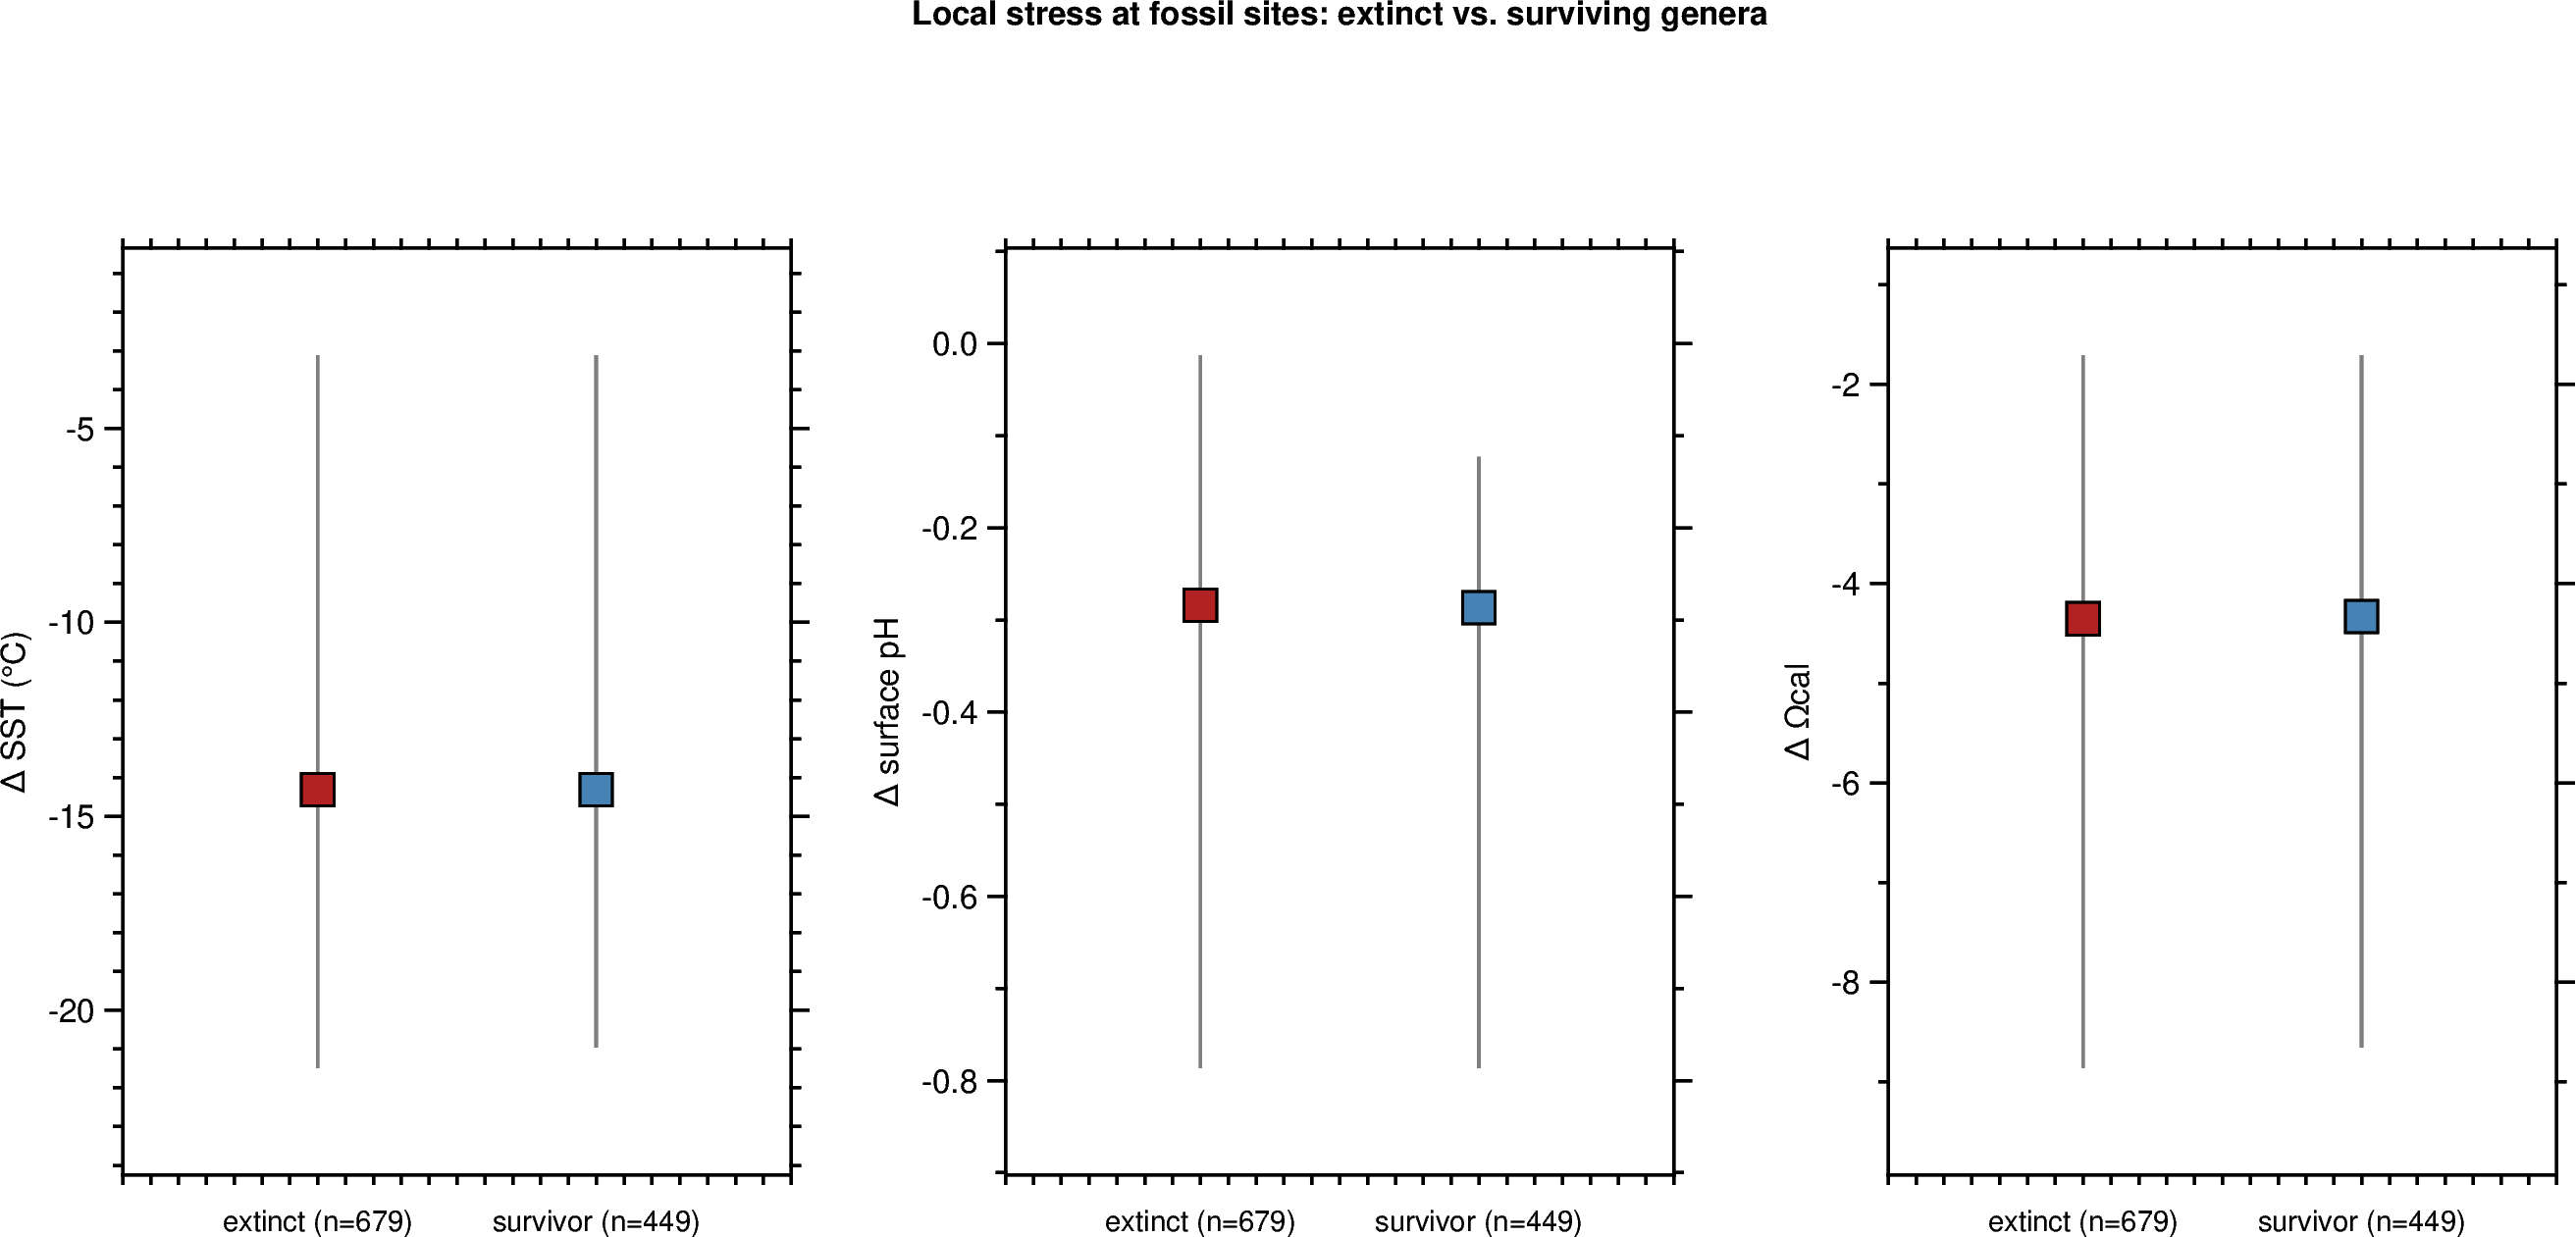

  genus-mean stress, extinct vs. survivor:
    Δ SST (°C)        extinct -14.5959   survivor -14.8284   difference +0.2325
    Δ surface pH      extinct -0.2884   survivor -0.2876   difference -0.0009
    Δ Ωcal            extinct -4.4348   survivor -4.4008   difference -0.0339


In [7]:
genus_stress = (maas_loc.groupby("genus")
                .agg(**{colname: (colname, "mean") for _, colname, _ in STRESS_FIELDS},
                     survived=("survived", "first"), n_occ=("genus", "size"))
                .reset_index())

fig = pygmt.Figure()
with fig.subplot(nrows=1, ncols=3, figsize=("21c", "8c"), margins=["0.7c", "1.4c"],
                  title="Local stress at fossil sites: extinct vs. surviving genera"):
    for panel_i, (var, colname, label) in enumerate(STRESS_FIELDS):
        extinct = genus_stress[~genus_stress["survived"]][colname]
        survive = genus_stress[genus_stress["survived"]][colname]
        y_min = min(extinct.min(), survive.min())
        y_max = max(extinct.max(), survive.max())
        pad = (y_max - y_min) * 0.15 or 0.05
        region = [-0.7, 1.7, y_min - pad, y_max + pad]
        with fig.set_panel(panel=panel_i):
            fig.basemap(region=region, projection="X?", frame=["WSne", "xf", f"yaf+l{label}"])
            for i, (vals, name) in enumerate([(extinct, "extinct"), (survive, "survivor")]):
                q1, med, q3 = np.percentile(vals, [25, 50, 75])
                fig.plot(x=[i, i], y=[vals.min(), vals.max()], pen="0.8p,gray50")
                fig.plot(x=[i], y=[med], style="s0.4c", fill="firebrick" if name == "extinct" else "steelblue",
                          pen="0.6p,black")
                fig.text(x=i, y=region[2], text=f"{name}\n(n={len(vals)})", offset="0/-0.3c",
                          justify="TC", font="7p", no_clip=True)
fig.savefig(OUTPUT_DIR / "T71_stress_extinct_vs_survivor.png", dpi=150)
fig.show(width=1050)

print("  genus-mean stress, extinct vs. survivor:")
for var, colname, label in STRESS_FIELDS:
    e = genus_stress[~genus_stress["survived"]][colname].mean()
    s = genus_stress[genus_stress["survived"]][colname].mean()
    print(f"    {label:16s}  extinct {e:+.4f}   survivor {s:+.4f}   difference {e - s:+.4f}")


**Result: essentially no difference.** At this model's coarse (36x36) spatial resolution, and at this snapshot in time, the genus-mean local stress is nearly identical between genera that went extinct and genera that survived — the hypothesis "worse local conditions predict local extinction" is **not supported** by this comparison. That is itself informative: it is consistent with the impact winter being a *globally synchronous* kill mechanism (darkness collapsing photosynthesis-based food webs everywhere at once, as T69 §5's globally-averaged time series already suggested, and as Ying et al. 2026's own model-based conclusion that impact-driven darkness — not spatially patchy local stress — drove most of the observed extinction pattern) rather than a geographically patchy one that would leave a spatial fingerprint on extinction risk. The map below shows this directly — extinct and surviving genera are both scattered across the full range of the (globally severe) stress field, with no obvious spatial segregation.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


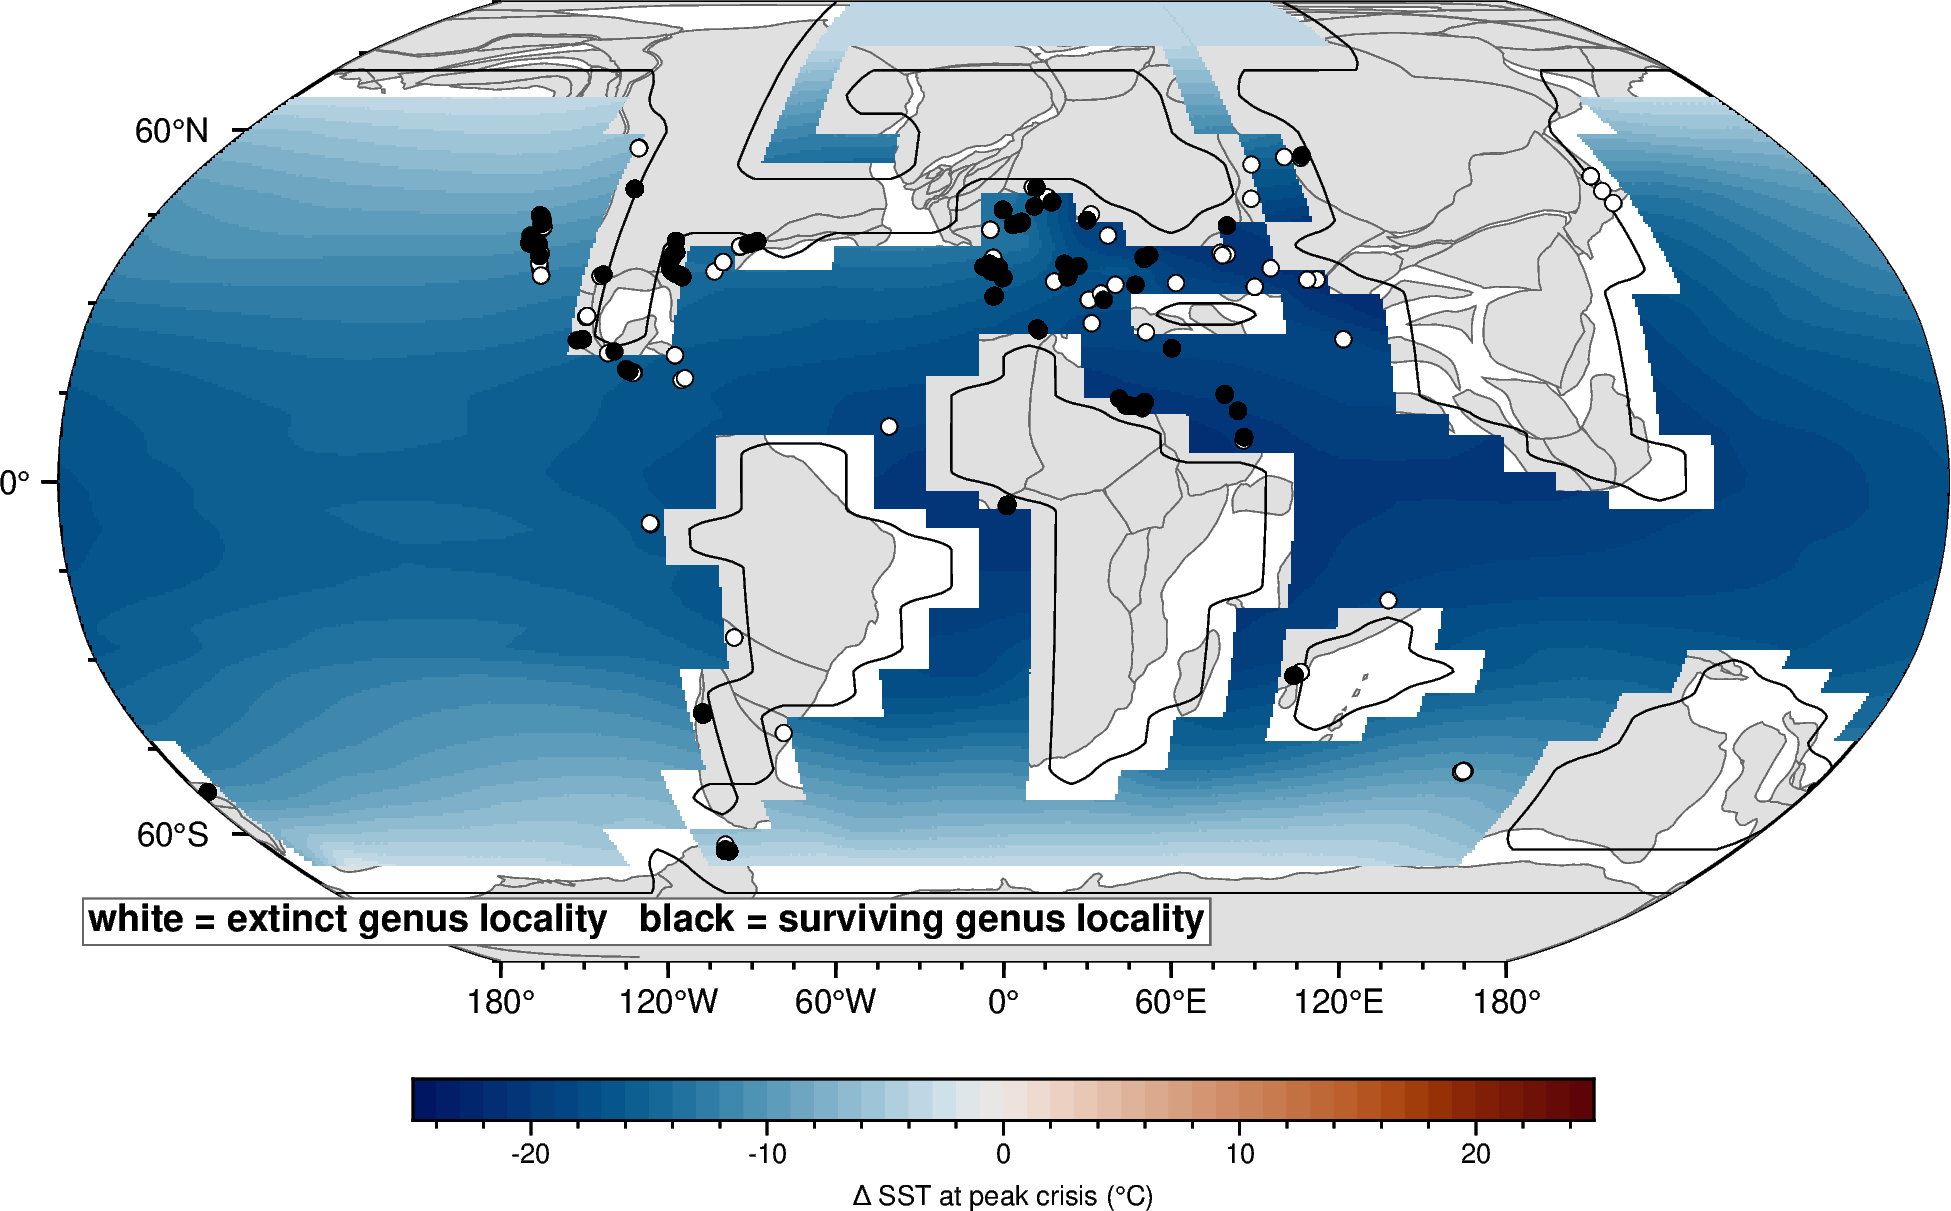

In [8]:
pmm2 = PlateModelManager()
model2 = pmm2.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon2 = gplately.PlateReconstruction(
    rotation_model=model2.get_rotation_model(),
    topology_features=model2.get_topologies(),
    static_polygons=model2.get_static_polygons(),
)
gm = gplately.PlotTopologies(
    plate_reconstruction=recon2,
    continents=model2.get_continental_polygons(),
    COBs=model2.get_COBs(),
    time=float(RECON_AGE_MA),
    plot_engine=gplately.PygmtPlotEngine(),
)

base_sst = base["ocn_sur_temp"].where(base["grid_mask"] > 0)
peak_sst = peak["ocn_sur_temp"].where(peak["grid_mask"] > 0)
dsst_field = refine_for_plot(peak_sst - base_sst)
# Smooth, contourable 0/1 mask (ocean=1, land=0) for grdcontour -- see T69 SS2 for why
# this needs to start from an explicit 0/1 field rather than the raw NaN-for-land mask.
mask_plot = refine_for_plot(xr.where(np.isnan(base["grid_mask"]), 0.0, 1.0))

fig = pygmt.Figure()
pygmt.makecpt(cmap="vik", series=[-25, 25, 1], background="o")
fig.basemap(region=REGION, projection=PROJ, frame="af")
gm.plot_continents(fig, fill="gray88", pen="0.3p,gray40")
fig.grdimage(grid=dsst_field, nan_transparent=True)
fig.grdcontour(grid=mask_plot, levels=[0.5], pen="0.4p,black")
fig.colorbar(frame="af+l\u0394 SST at peak crisis (\u00b0C)", position="JBC+w10c/0.35c+h+o0/1c")
for name, colour in [(False, "white"), (True, "black")]:
    sub = genus_stress[genus_stress["survived"] == name].merge(
        maas_loc[["genus", "paleo_lon", "paleo_lat"]].drop_duplicates("genus"), on="genus")
    fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"], style="c0.14c", fill=colour, pen="0.3p,black")
fig.text(text="white = extinct genus locality   black = surviving genus locality",
          position="BL", offset="0.25c/0.25c", justify="BL",
          font="9p,Helvetica-Bold,black", fill="white", pen="0.4p,gray40")
fig.savefig(OUTPUT_DIR / "T71_extinction_map.png", dpi=150)
fig.show(width=800)


**What this shows.** White (extinct-genus) and black (surviving-genus) points are interleaved everywhere fossil localities exist, with no visible clustering of either colour into the most-severe (darkest blue) or least-severe (palest) ΔSST regions — the spatial pattern a reader would expect *if* local stress magnitude were the dominant control on extinction risk simply is not there. Both colours also concentrate heavily in the mid-to-low latitude shelf regions where marine invertebrate fossils are best preserved and sampled, a sampling-distribution feature of the fossil record itself rather than a model result. The reconstructed continent fill (gray, Scotese & Wright 2018, matching cGENIE's own paleogeography) makes clear that essentially every plotted locality sits on or immediately adjacent to a reconstructed continental margin, consistent with §3's near-zero locality drop-out rate.

## 6. Test 2 — does taxonomic identity predict extinction rate?

The classic alternative: extinction rate by class, independent of locality. This is well-trodden ground in K-Pg paleontology (ammonites' total extinction is one of the most famous facts about the boundary), included here as a direct comparison against Test 1 — and because it connects back to T70's model-internal finding that *trait identity* (cell size, trophic strategy), not spatial position, predicted plankton survival. The same pattern shows up independently in the real fossil record at a coarser taxonomic level.

                survival_rate  n_genera
class                                  
Cephalopoda          0.026667        75
Rhynchonellata       0.111111        54
Bivalvia             0.337526       477
Tubothalamea         0.363636        11
Gastropoda           0.469388       392
Echinoidea           0.505376        93
Globothalamea        0.803571        56
Nodosariata          0.806452        31


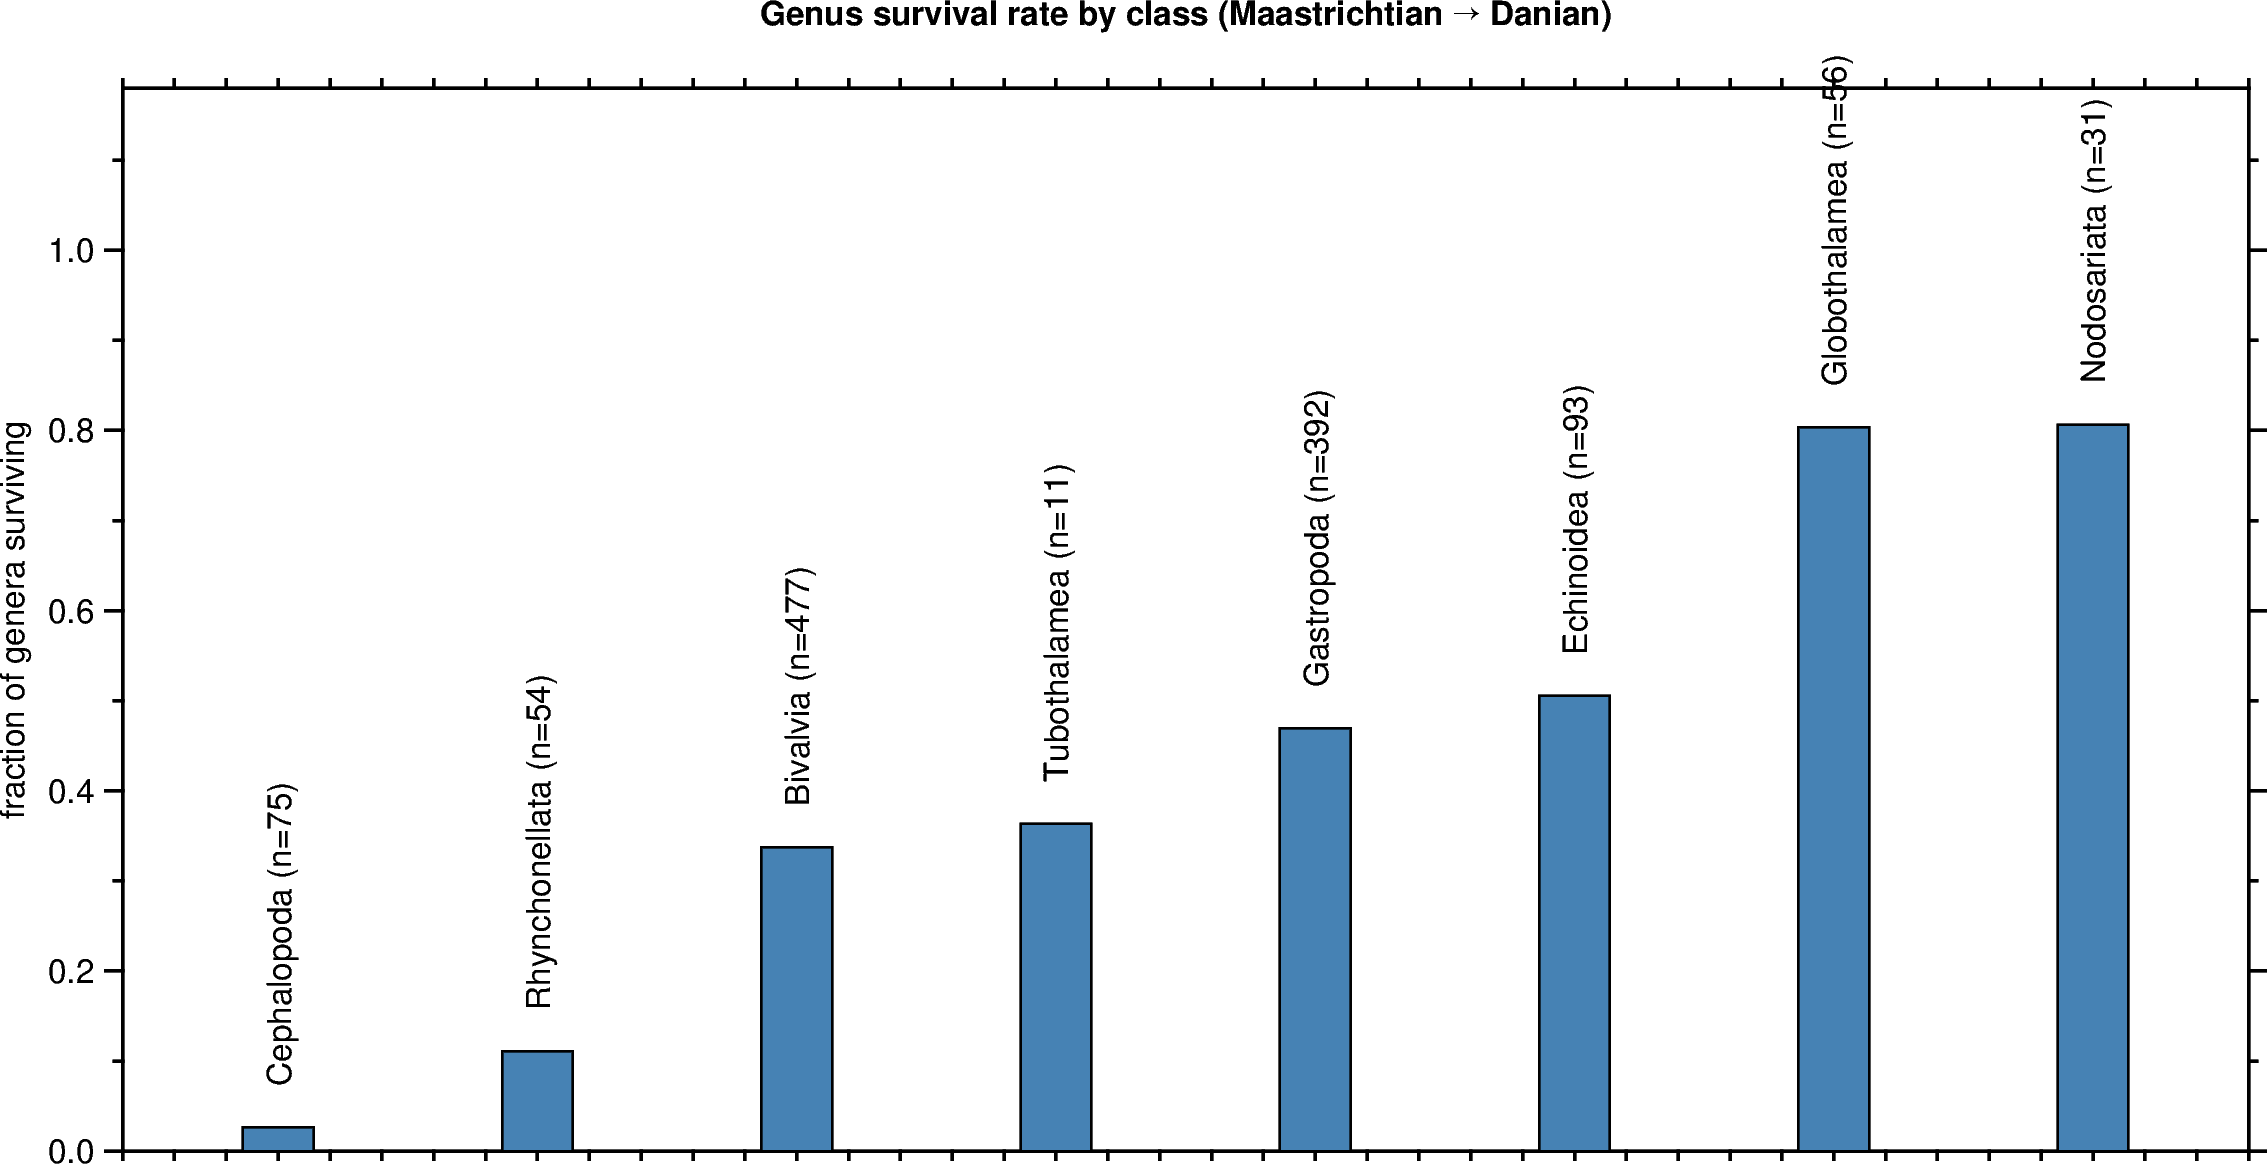

In [9]:
# PBDB returns the literal string "NO_CLASS_SPECIFIED" for occurrences with
# no class-level identification -- drop it here, it is a data-completeness
# artefact, not a taxon.
by_class = (maas_genus[maas_genus["class"] != "NO_CLASS_SPECIFIED"]
            .groupby("class")["survived"]
            .agg(survival_rate="mean", n_genera="count")
            .query("n_genera >= 10")
            .sort_values("survival_rate"))
print(by_class)

fig = pygmt.Figure()
region = [-0.6, len(by_class) - 0.4, 0, 1.18]
fig.basemap(region=region, projection="X18c/9c",
            frame=["Wsne+tGenus survival rate by class (Maastrichtian \u2192 Danian)", "xf",
                   "yaf+lfraction of genera surviving"])
# draw all bars first, then all labels on top, so no label is ever painted
# over by a later bar
for i, (cls, row) in enumerate(by_class.iterrows()):
    fig.plot(x=[i], y=[row["survival_rate"]], style="b0.6c+b0", fill="steelblue", pen="0.5p,black")
for i, (cls, row) in enumerate(by_class.iterrows()):
    n_g = row["n_genera"]
    fig.text(x=i, y=row["survival_rate"], text=f"{cls} (n={n_g:.0f})", offset="0/0.35c",
              angle=90, justify="ML", font="8p", no_clip=True)
fig.savefig(OUTPUT_DIR / "T71_survival_by_class.png", dpi=150)
fig.show(width=900)


**What this shows.** Unlike Test 1's null result, class identity separates survival rate clearly: the lowest bars are consistently ammonite- and rudist-type groups with total or near-total loss (the single most famous fact about the K-Pg boundary), while the highest bars belong to groups with comparatively strong survivorship. This is the taxonomic-selectivity signature Test 1's *spatial* test could not find — extinction risk here tracks *who you are* far more strongly than *where you happened to be*, echoing T70's model-internal result that trait identity (cell size, trophic strategy), not spatial position, predicted plankton survival. Note the two results are not in tension: a globally synchronous kill mechanism (§5) is entirely compatible with strongly taxon-selective mortality (§6) if different taxa's physiology and ecology make them differently vulnerable to the *same* global stress, rather than different taxa simply experiencing different amounts of stress.

## Extend this

- **Weight by sampling effort.** §2's simple boundary-crosser method doesn't correct for the Signor-Lipps effect or uneven collection intensity. PBDB's own occurrence counts per stage could be used to down-weight genera known from very few Maastrichtian samples, which are more likely to show a false "extinction" from under-sampling alone.
- **Push the stress test further back in time.** §5's null result used the peak-crisis snapshot only. Try sampling the biogeochemical field 100 years post-impact (T69's `main_t199.5`) or well into the Danian recovery (T69's `danian_t*` snapshots) instead — a longer-duration, cumulative stress metric (e.g. time-integrated ΔpH) might show a relationship the instantaneous peak-crisis snapshot misses.
- **Cross-reference T70's foraminifera guilds.** §6 already shows two foram classes (`Globothalamea`, `Nodosariata`) among the surviving groups — T70 §3's `foram_bn`/`foram_sn` model PFTs are a direct modelled analogue. Do the model's simulated foraminifera also do comparatively well in the `main` experiment's biomass collapse?
- **Try a finer taxonomic or ecological grouping.** Class-level pooling is coarse — within Bivalvia, epifaunal filter-feeders and infaunal deposit-feeders are known to have fared differently. PBDB's `show=ecospace` parameter returns life-habit codes that could refine §6.

## Related notebooks

- **T69** — K-Pg impact winter: ocean biogeochemistry collapse and recovery. Source of the stress fields sampled here.
- **T70** — Trait-based extinction selectivity in the K-Pg plankton collapse (EcoGEM). The model-internal analogue of this notebook's taxonomic-selectivity test.
- **T60** — PBDB paleobiogeography workflow. Source of the live-query pattern reused in §2.
- **T61** — Paleo-bioregionalization via H3 + hierarchical clustering. Another PBDB + `gplately` reconstruction workflow.

## References

Ying, R., Monteiro, F. M., Witts, J. D. & Schmidt, D. N. (2026). Darkness and body size shaped end-Cretaceous marine extinction patterns. *Nature* 655, 957-962. https://doi.org/10.1038/s41586-026-10541-4 (Open Access, CC BY 4.0).

Model output data: Ying, R. (2026). *cGENIE model outputs for KPG study* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.17742290 (CC BY 4.0).

Model code: https://github.com/ruiying-ocean/cgenie.muffin/tree/rui_kpg. Analysis code: https://github.com/ruiying-ocean/cgeniepy (see also Ying, R. (2024). cgeniepy: A Python package for analysing cGENIE Earth System Model output. *Journal of Open Source Software* 9(101), 6762. https://doi.org/10.21105/joss.06762). Figure/selectivity-analysis code: https://github.com/ruiying-ocean/kpg_selectivity

Peters, S.E. & McClennen, M. (2016). The Paleobiology Database application programming interface. *Paleobiology* 42(1), 1-7. https://doi.org/10.1017/pab.2015.39

Signor, P.W. & Lipps, J.H. (1982). Sampling bias, gradual extinction patterns and catastrophes in the fossil record. In: *Geological Implications of Impacts of Large Asteroids and Comets on the Earth*, Geological Society of America Special Paper 190, 291-296.

Scotese, C.R. & Wright, N. (2018). PALEOMAP Paleodigital Elevation Models (PaleoDEMS) for the Phanerozoic. https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/

Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
